<a href="https://colab.research.google.com/github/Shahidrrs/nutribone3/blob/main/nutribone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
import random
import seaborn as sns

In [ ]:
import kagglehub

print("Downloading dataset 1 (mohamedgobara)...")
path1 = kagglehub.dataset_download("mohamedgobara/multi-class-knee-osteoporosis-x-ray-dataset")
print("Dataset 1 path:", path1)

print("\nDownloading dataset 2 (stevepython)...")
path2 = kagglehub.dataset_download("stevepython/osteoporosis-knee-xray-dataset")
print("Dataset 2 path:", path2)

Using Colab cache for faster access to the 'multi-class-knee-osteoporosis-x-ray-dataset' dataset.
Dataset 1 path: /kaggle/input/multi-class-knee-osteoporosis-x-ray-dataset

Using Colab cache for faster access to the 'osteoporosis-knee-xray-dataset' dataset.
Dataset 2 path: /kaggle/input/osteoporosis-knee-xray-dataset


In [ ]:
import random
import shutil
import os
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

random.seed(42)
np.random.seed(42)

if os.path.exists("/tmp/osteoporosis_merged"):
    shutil.rmtree("/tmp/osteoporosis_merged")
    print("Old merged folder deleted.")

merged_dir = "/tmp/osteoporosis_merged"
splits     = ['train', 'val', 'test']
classes    = ['Normal', 'Osteopenia', 'Osteoporosis']

targets = {
    'train': 724,
    'val':   144,
    'test':  98
}

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(merged_dir, split, cls), exist_ok=True)

def collect_images(src_dir):
    if not os.path.exists(src_dir):
        print(f"  WARNING: Not found: {src_dir}")
        return []
    return [
        os.path.join(src_dir, f)
        for f in os.listdir(src_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]

def split_and_copy(image_paths, dst_class_dirs, label_prefix, train=0.75, val=0.15):
    random.shuffle(image_paths)
    n       = len(image_paths)
    n_train = int(n * train)
    n_val   = int(n * val)
    splits_map = {
        'train': image_paths[:n_train],
        'val':   image_paths[n_train:n_train + n_val],
        'test':  image_paths[n_train + n_val:]
    }
    counts = {}
    for split_name, paths in splits_map.items():
        dst = dst_class_dirs[split_name]
        for i, src in enumerate(paths):
            ext = os.path.splitext(src)[1].lower()
            shutil.copy2(src, os.path.join(dst, f"{label_prefix}_{i}{ext}"))
        counts[split_name] = len(paths)
    return counts

def augment_to_exact(src_dir, target_count, label_prefix='aug'):
    existing = [
        os.path.join(src_dir, f)
        for f in os.listdir(src_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]
    current = len(existing)
    if current > target_count:
        to_remove = random.sample(existing, current - target_count)
        for f in to_remove:
            os.remove(f)
        print(f"  Trimmed {current} → {target_count}")
        return
    if current < target_count:
        aug = ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.15,
            horizontal_flip=True,
            brightness_range=[0.8, 1.2],
            shear_range=0.1,
            fill_mode='nearest'
        )
        needed = target_count - current
        idx = 0
        print(f"  Augmenting {current} → {target_count} (need {needed})...")
        while idx < needed:
            src_img_path = random.choice(existing)
            try:
                img = load_img(src_img_path, target_size=(224, 224))
                x   = img_to_array(img).reshape((1, 224, 224, 3))
                for batch in aug.flow(x, batch_size=1):
                    Image.fromarray(batch[0].astype(np.uint8)).save(
                        os.path.join(src_dir, f"{label_prefix}_{idx}.jpg"))
                    idx += 1
                    break
            except Exception as e:
                continue
        print(f"  Done: {len(os.listdir(src_dir))} images")

d1_base    = os.path.join(path1, "OS Collected Data")
d1_sources = {
    'Normal':       os.path.join(d1_base, "Normal"),
    'Osteopenia':   os.path.join(d1_base, "Osteopenia"),
    'Osteoporosis': os.path.join(d1_base, "Osteoporosis"),
}
d2_sources = {
    'Normal':       os.path.join(path2, "normal", "normal"),
    'Osteoporosis': os.path.join(path2, "osteoporosis", "osteoporosis"),
}

for cls in classes:
    dst_dirs = {s: os.path.join(merged_dir, s, cls) for s in splits}
    imgs_d1  = collect_images(d1_sources.get(cls, ""))
    imgs_d2  = collect_images(d2_sources.get(cls, ""))
    counts1  = split_and_copy(imgs_d1, dst_dirs, label_prefix="d1")
    counts2  = split_and_copy(imgs_d2, dst_dirs, label_prefix="d2")
    print(f"\n{cls}: {len(imgs_d1)} D1 + {len(imgs_d2)} D2 = {len(imgs_d1)+len(imgs_d2)}")

print("\nBalancing classes...")
for cls in classes:
    for split_name in splits:
        target    = targets[split_name]
        split_dir = os.path.join(merged_dir, split_name, cls)
        augment_to_exact(split_dir, target, label_prefix=f'aug_{cls[:3].lower()}')

print("\nFinal summary:")
for split in splits:
    print(f"\n{split}/")
    for cls in classes:
        n = len(os.listdir(os.path.join(merged_dir, split, cls)))
        print(f"  {cls}: {n}")


Normal: 780 D1 + 186 D2 = 966

Osteopenia: 374 D1 + 0 D2 = 374

Osteoporosis: 793 D1 + 186 D2 = 979

Balancing classes...
  Augmenting 280 → 724 (need 444)...
  Done: 724 images
  Augmenting 56 → 144 (need 88)...
  Done: 144 images
  Augmenting 38 → 98 (need 60)...
  Done: 98 images
  Trimmed 733 → 724
  Trimmed 145 → 144
  Trimmed 101 → 98

Final summary:

train/
  Normal: 724
  Osteopenia: 724
  Osteoporosis: 724

val/
  Normal: 144
  Osteopenia: 144
  Osteoporosis: 144

test/
  Normal: 98
  Osteopenia: 98
  Osteoporosis: 98


In [ ]:
train_dir = os.path.join(merged_dir, 'train')
val_dir   = os.path.join(merged_dir, 'val')
test_dir  = os.path.join(merged_dir, 'test')

def make_generators(preprocess_fn, batch_size=16):
    train_datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        brightness_range=[0.85, 1.15],
        fill_mode='nearest',
        preprocessing_function=preprocess_fn
    )
    val_datagen  = ImageDataGenerator(preprocessing_function=preprocess_fn)
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    train_gen = train_datagen.flow_from_directory(
        train_dir, target_size=(224, 224), batch_size=batch_size,
        classes=['Normal', 'Osteopenia', 'Osteoporosis'],
        class_mode='categorical', shuffle=True
    )
    val_gen = val_datagen.flow_from_directory(
        val_dir, target_size=(224, 224), batch_size=batch_size,
        classes=['Normal', 'Osteopenia', 'Osteoporosis'],
        class_mode='categorical', shuffle=False
    )
    test_gen = test_datagen.flow_from_directory(
        test_dir, target_size=(224, 224), batch_size=1,
        classes=['Normal', 'Osteopenia', 'Osteoporosis'],
        class_mode='categorical', shuffle=False
    )
    return train_gen, val_gen, test_gen

def build_model(backbone, preprocess_fn_name):
    inputs     = layers.Input(shape=(224, 224, 3))
    backbone.trainable = False
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    return models.Model(inputs, outputs)

print("Helper functions ready.")

Helper functions ready.


In [ ]:
print("=" * 50)
print("TRAINING MODEL 1: VGG-19")
print("=" * 50)

preprocess_vgg = tf.keras.applications.vgg19.preprocess_input
train_gen, val_gen, test_gen = make_generators(preprocess_vgg)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights_array))

# Build VGG-19
vgg_base = tf.keras.applications.VGG19(
    include_top=False, weights='imagenet', input_shape=(224, 224, 3))
model_vgg = build_model(vgg_base, 'vgg19')

# Stage 1
model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_s1 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint("vgg19_stage1.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("\nVGG-19 Stage 1...")
h_vgg1 = model_vgg.fit(train_gen, validation_data=val_gen,
                        epochs=20, callbacks=cb_s1,
                        class_weight=class_weights)

# Stage 2 — unfreeze block4 + block5
vgg_base.trainable = True
for layer in vgg_base.layers:
    layer.trainable = 'block5' in layer.name or 'block4' in layer.name

model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_s2 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-9, verbose=1),
    ModelCheckpoint("vgg19_best.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("\nVGG-19 Stage 2...")
h_vgg2 = model_vgg.fit(train_gen, validation_data=val_gen,
                        epochs=40, callbacks=cb_s2,
                        class_weight=class_weights)

print(f"\nVGG-19 Best Val Accuracy: {max(h_vgg2.history['val_accuracy']):.4f}")

TRAINING MODEL 1: VGG-19
Found 2172 images belonging to 3 classes.
Found 432 images belonging to 3 classes.
Found 294 images belonging to 3 classes.
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

VGG-19 Stage 1...
Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.5319 - loss: 1.3297
Epoch 1: val_accuracy improved from None to 0.70602, saving model to vgg19_stage1.keras

Epoch 1: finished saving model to vgg19_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 107s 690ms/step - accuracy: 0.5764 - loss: 1.2279 - val_accuracy: 0.7060 - val_loss: 0.7572 - learning_rate: 0.0010
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.6586 - loss: 0.9741
Epoch 2: val_accuracy improved from 0.70602 to 0.71528, saving model to vgg19_stage1.keras

Epoch 2: finished saving model to vgg19_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 87s 639ms/step - accuracy: 0.6777 - loss: 0.9303 - val_accuracy: 0.7153 - val_loss: 0.7509 - learning_rate: 0.0010
Epoch 3/20
136/136 ━━━━━━━━━━

In [ ]:
print("=" * 50)
print("TRAINING MODEL 2: ResNet50")
print("=" * 50)

preprocess_res = tf.keras.applications.resnet50.preprocess_input
train_gen_r, val_gen_r, test_gen_r = make_generators(preprocess_res)

res_base = tf.keras.applications.ResNet50(
    include_top=False, weights='imagenet', input_shape=(224, 224, 3))
model_res = build_model(res_base, 'resnet50')

# Stage 1
model_res.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_r1 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint("resnet50_stage1.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("\nResNet50 Stage 1...")
h_res1 = model_res.fit(train_gen_r, validation_data=val_gen_r,
                        epochs=20, callbacks=cb_r1,
                        class_weight=class_weights)

# Stage 2 — unfreeze last 40 layers
res_base.trainable = True
for layer in res_base.layers[:-40]:
    layer.trainable = False

model_res.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_r2 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-9, verbose=1),
    ModelCheckpoint("resnet50_best.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("\nResNet50 Stage 2...")
h_res2 = model_res.fit(train_gen_r, validation_data=val_gen_r,
                        epochs=40, callbacks=cb_r2,
                        class_weight=class_weights)

print(f"\nResNet50 Best Val Accuracy: {max(h_res2.history['val_accuracy']):.4f}")

TRAINING MODEL 2: ResNet50
Found 2172 images belonging to 3 classes.
Found 432 images belonging to 3 classes.
Found 294 images belonging to 3 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

ResNet50 Stage 1...
Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.6038 - loss: 1.2234
Epoch 1: val_accuracy improved from None to 0.71296, saving model to resnet50_stage1.keras

Epoch 1: finished saving model to resnet50_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 108s 674ms/step - accuracy: 0.6648 - loss: 1.0420 - val_accuracy: 0.7130 - val_loss: 0.7449 - learning_rate: 0.0010
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.6733 - loss: 0.9572
Epoch 2: val_accuracy improved from 0.71296 to 0.75463, saving model to resnet50_stage1.keras

Epoch 2: finished saving model to resnet50_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 122s 585ms/step - accuracy: 0.6952 - loss: 0.8855 - val_accuracy: 0.7546 - val_loss: 0.7166 - learning_rate: 0.0010
Epoch 3/20
1

In [ ]:
print("=" * 50)
print("TRAINING MODEL 3: EfficientNetB0")
print("=" * 50)

preprocess_eff = tf.keras.applications.efficientnet.preprocess_input
train_gen_e, val_gen_e, test_gen_e = make_generators(preprocess_eff)

eff_base = tf.keras.applications.EfficientNetB0(
    include_top=False, weights='imagenet', input_shape=(224, 224, 3))
model_eff = build_model(eff_base, 'efficientnet')

# Stage 1
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_e1 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint("effnet_stage1.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("\nEfficientNetB0 Stage 1...")
h_eff1 = model_eff.fit(train_gen_e, validation_data=val_gen_e,
                        epochs=20, callbacks=cb_e1,
                        class_weight=class_weights)

# Stage 2 — unfreeze top 30%
eff_base.trainable = True
freeze_until = int(len(eff_base.layers) * 0.7)
for layer in eff_base.layers[:freeze_until]:
    layer.trainable = False

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_e2 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-9, verbose=1),
    ModelCheckpoint("effnet_best.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("\nEfficientNetB0 Stage 2...")
h_eff2 = model_eff.fit(train_gen_e, validation_data=val_gen_e,
                        epochs=40, callbacks=cb_e2,
                        class_weight=class_weights)

print(f"\nEfficientNetB0 Best Val Accuracy: {max(h_eff2.history['val_accuracy']):.4f}")

TRAINING MODEL 3: EfficientNetB0
Found 2172 images belonging to 3 classes.
Found 432 images belonging to 3 classes.
Found 294 images belonging to 3 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

EfficientNetB0 Stage 1...
Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.5803 - loss: 1.2541
Epoch 1: val_accuracy improved from None to 0.70602, saving model to effnet_stage1.keras

Epoch 1: finished saving model to effnet_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 138s 774ms/step - accuracy: 0.6542 - loss: 1.0649 - val_accuracy: 0.7060 - val_loss: 0.7583 - learning_rate: 0.0010
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.7053 - loss: 0.8579
Epoch 2: val_accuracy improved from 0.70602 to 0.71296, saving model to effnet_stage1.keras

Epoch 2: finished saving model to effnet_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 77s 565ms/step - accuracy: 0.7021 - loss: 0.8582 - val_accuracy: 0.7130 - val_loss: 0.7187 - learning_rate: 0.0010
Epoch 3/2

In [ ]:
print("=" * 50)
print("TRAINING MODEL 4: ResNet50V2")
print("=" * 50)

preprocess_res2 = tf.keras.applications.resnet_v2.preprocess_input
train_gen_r2, val_gen_r2, test_gen_r2 = make_generators(preprocess_res2)

res_base_v2 = tf.keras.applications.ResNet50V2(
    include_top=False, weights='imagenet', input_shape=(224, 224, 3))
model_res2 = build_model(res_base_v2, 'resnet50v2')

# Stage 1
model_res2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_r2s1 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint("resnet50v2_stage1.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("\nResNet50V2 Stage 1...")
h_res2s1 = model_res2.fit(train_gen_r2, validation_data=val_gen_r2,
                           epochs=20, callbacks=cb_r2s1,
                           class_weight=class_weights)

# Stage 2 — unfreeze last 40 layers
res_base_v2.trainable = True
for layer in res_base_v2.layers[:-40]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in res_base_v2.layers if l.trainable)}")

model_res2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_r2s2 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-9, verbose=1),
    ModelCheckpoint("resnet50v2_best.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("\nResNet50V2 Stage 2...")
h_res2s2 = model_res2.fit(train_gen_r2, validation_data=val_gen_r2,
                           epochs=40, callbacks=cb_r2s2,
                           class_weight=class_weights)

print(f"\nResNet50V2 Best Val Accuracy: {max(h_res2s2.history['val_accuracy']):.4f}")

TRAINING MODEL 4: ResNet50V2
Found 2172 images belonging to 3 classes.
Found 432 images belonging to 3 classes.
Found 294 images belonging to 3 classes.
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

ResNet50V2 Stage 1...
Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.5975 - loss: 1.2875
Epoch 1: val_accuracy improved from None to 0.67130, saving model to resnet50v2_stage1.keras

Epoch 1: finished saving model to resnet50v2_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 104s 653ms/step - accuracy: 0.6423 - loss: 1.1379 - val_accuracy: 0.6713 - val_loss: 0.8140 - learning_rate: 0.0010
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.6881 - loss: 0.9014
Epoch 2: val_accuracy improved from 0.67130 to 0.74769, saving model to resnet50v2_stage1.keras

Epoch 2: finished saving model to resnet50v2_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 78s 577ms/step - accuracy: 0.6782 - loss: 0.9355 - val_accuracy: 0.7477 - val_loss: 0.6911 - learning_rate: 0.0010
E

In [ ]:
print("Loading all 4 best models...")
m_vgg  = tf.keras.models.load_model("vgg19_best.keras")
m_res  = tf.keras.models.load_model("resnet50_best.keras")
m_eff  = tf.keras.models.load_model("effnet_best.keras")
m_res2 = tf.keras.models.load_model("resnet50v2_best.keras")

class_names = ['Normal', 'Osteopenia', 'Osteoporosis']

def get_preds(model, preprocess_fn, n_tta=20):
    """Get TTA predictions from a model."""
    tta_datagen = ImageDataGenerator(
        rotation_range=5,
        horizontal_flip=True,
        zoom_range=0.03,
        preprocessing_function=preprocess_fn
    )
    # Get total test samples
    total = sum(
        len(os.listdir(os.path.join(test_dir, cls)))
        for cls in ['Normal', 'Osteopenia', 'Osteoporosis']
    )
    preds = np.zeros((total, 3))

    for i in range(n_tta):
        gen = tta_datagen.flow_from_directory(
            test_dir, target_size=(224, 224), batch_size=1,
            classes=['Normal', 'Osteopenia', 'Osteoporosis'],
            class_mode='categorical', shuffle=False)
        gen.reset()
        preds += model.predict(gen, steps=len(gen), verbose=0)
        print(f"  TTA round {i+1}/{n_tta} done")
    return preds / n_tta

# VGG-19 and ResNet50 are strongest — give them 30 TTA rounds
print("\nVGG-19 predictions (30 TTA rounds)...")
preds_vgg = get_preds(m_vgg,
                      tf.keras.applications.vgg19.preprocess_input,
                      n_tta=30)

print("\nResNet50 predictions (30 TTA rounds)...")
preds_res = get_preds(m_res,
                      tf.keras.applications.resnet50.preprocess_input,
                      n_tta=30)

# EfficientNetB0 and ResNet50V2 get 20 TTA rounds
print("\nEfficientNetB0 predictions (20 TTA rounds)...")
preds_eff = get_preds(m_eff,
                      tf.keras.applications.efficientnet.preprocess_input,
                      n_tta=20)

print("\nResNet50V2 predictions (20 TTA rounds)...")
preds_res2 = get_preds(m_res2,
                       tf.keras.applications.resnet_v2.preprocess_input,
                       n_tta=20)

# Get true labels
label_gen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg19.preprocess_input
).flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=1,
    classes=['Normal', 'Osteopenia', 'Osteoporosis'],
    class_mode='categorical', shuffle=False)
y_true = label_gen.classes

print("\nAll predictions done!")

Loading all 4 best models...

VGG-19 predictions (30 TTA rounds)...
Found 294 images belonging to 3 classes.
  TTA round 1/30 done
Found 294 images belonging to 3 classes.
  TTA round 2/30 done
Found 294 images belonging to 3 classes.
  TTA round 3/30 done
Found 294 images belonging to 3 classes.
  TTA round 4/30 done
Found 294 images belonging to 3 classes.
  TTA round 5/30 done
Found 294 images belonging to 3 classes.
  TTA round 6/30 done
Found 294 images belonging to 3 classes.
  TTA round 7/30 done
Found 294 images belonging to 3 classes.
  TTA round 8/30 done
Found 294 images belonging to 3 classes.
  TTA round 9/30 done
Found 294 images belonging to 3 classes.
  TTA round 10/30 done
Found 294 images belonging to 3 classes.
  TTA round 11/30 done
Found 294 images belonging to 3 classes.
  TTA round 12/30 done
Found 294 images belonging to 3 classes.
  TTA round 13/30 done
Found 294 images belonging to 3 classes.
  TTA round 14/30 done
Found 294 images belonging to 3 classes.
  TT


Searching for optimal ensemble weights...
(This may take ~1 minute)

Best weights:
  VGG-19:        1.2
  ResNet50:      0.4
  EfficientNetB0:0.2
  ResNet50V2:    0.6

Best Ensemble Accuracy: 89.12%

--- Final Ensemble Classification Report ---
              precision    recall  f1-score   support

      Normal       0.98      0.86      0.91        98
  Osteopenia       0.93      0.86      0.89        98
Osteoporosis       0.80      0.96      0.87        98

    accuracy                           0.89       294
   macro avg       0.90      0.89      0.89       294
weighted avg       0.90      0.89      0.89       294



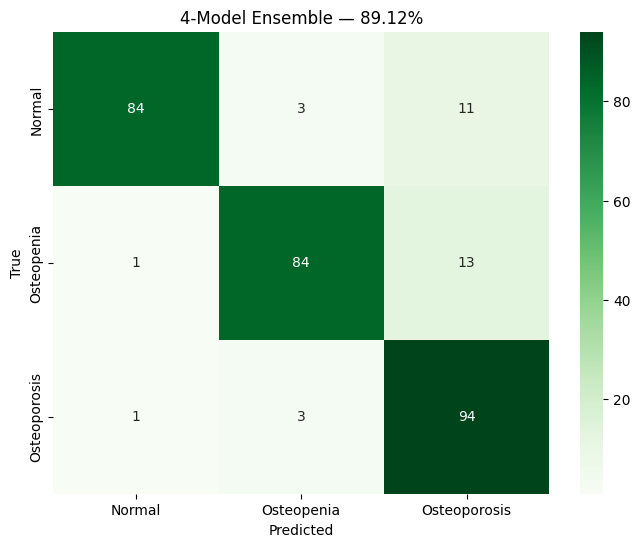

In [ ]:
print("\nSearching for optimal ensemble weights...")
print("(This may take ~1 minute)")

best_acc   = 0
best_w     = (1, 1, 1, 1)
best_preds = None

# Search weight combinations for all 4 models
for w1 in np.arange(0.2, 1.3, 0.2):      # VGG-19
    for w2 in np.arange(0.2, 1.3, 0.2):   # ResNet50
        for w3 in np.arange(0.2, 1.1, 0.2): # EfficientNetB0
            for w4 in np.arange(0.2, 1.3, 0.2): # ResNet50V2
                ensemble = (w1*preds_vgg + w2*preds_res +
                            w3*preds_eff + w4*preds_res2)
                y_pred   = np.argmax(ensemble, axis=1)
                acc      = np.sum(y_pred == y_true) / len(y_true)
                if acc > best_acc:
                    best_acc   = acc
                    best_w     = (w1, w2, w3, w4)
                    best_preds = ensemble.copy()

print(f"\nBest weights:")
print(f"  VGG-19:        {best_w[0]:.1f}")
print(f"  ResNet50:      {best_w[1]:.1f}")
print(f"  EfficientNetB0:{best_w[2]:.1f}")
print(f"  ResNet50V2:    {best_w[3]:.1f}")
print(f"\nBest Ensemble Accuracy: {best_acc * 100:.2f}%")

y_pred_final = np.argmax(best_preds, axis=1)

print("\n--- Final Ensemble Classification Report ---")
print(classification_report(y_true, y_pred_final, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'4-Model Ensemble — {best_acc*100:.2f}%')
plt.show()

In [ ]:
print("\nFull model comparison:")
print("-" * 45)

results = {
    "VGG-19 (30 TTA)":        preds_vgg,
    "ResNet50 (30 TTA)":      preds_res,
    "EfficientNetB0 (20 TTA)":preds_eff,
    "ResNet50V2 (20 TTA)":    preds_res2,
    "Equal Ensemble (4 models)":(preds_vgg + preds_res +
                                  preds_eff + preds_res2) / 4,
    "Weighted Ensemble":       best_preds
}

for name, preds in results.items():
    y_p = np.argmax(preds, axis=1)
    acc = np.sum(y_p == y_true) / len(y_true)
    print(f"{name:30s}: {acc*100:.2f}%")

print(f"\nPrevious best (3-model ensemble): 89.46%")
print(f"New best (4-model ensemble):      {best_acc*100:.2f}%")
improvement = best_acc * 100 - 89.46
print(f"Improvement:                      +{improvement:.2f}%")


Full model comparison:
---------------------------------------------
VGG-19 (30 TTA)               : 87.07%
ResNet50 (30 TTA)             : 88.44%
EfficientNetB0 (20 TTA)       : 84.35%
ResNet50V2 (20 TTA)           : 85.37%
Equal Ensemble (4 models)     : 87.76%
Weighted Ensemble             : 89.12%

Previous best (3-model ensemble): 89.46%
New best (4-model ensemble):      89.12%
Improvement:                      +-0.34%


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_dir = "/tmp/osteoporosis_merged/test"

label_gen = ImageDataGenerator(
 preprocessing_function=tf.keras.applications.vgg19.preprocess_input
).flow_from_directory(
 test_dir, target_size=(224, 224), batch_size=1,
 classes=['Normal', 'Osteopenia', 'Osteoporosis'],
 class_mode='categorical', shuffle=False)
y_true_current = label_gen.classes

def quick_predict(model, preprocess_fn):
 gen = ImageDataGenerator(
  preprocessing_function=preprocess_fn
 ).flow_from_directory(
  test_dir, target_size=(224, 224), batch_size=1,
  classes=['Normal', 'Osteopenia', 'Osteoporosis'],
  class_mode='categorical', shuffle=False)
 gen.reset()
 preds = model.predict(gen, steps=len(gen), verbose=0)
 return preds

print("Getting predictions...")
p_vgg = quick_predict(m_vgg, tf.keras.applications.vgg19.preprocess_input)
p_res = quick_predict(m_res, tf.keras.applications.resnet50.preprocess_input)
p_eff = quick_predict(m_eff, tf.keras.applications.efficientnet.preprocess_input)
p_res2 = quick_predict(m_res2, tf.keras.applications.resnet_v2.preprocess_input)

old_3 = (p_vgg + p_res + p_eff) / 3
acc_old3 = np.sum(np.argmax(old_3, axis=1) == y_true_current) / len(y_true_current)

new_4 = (0.6*p_vgg + 1.0*p_res + 0.2*p_eff + 0.2*p_res2)
acc_new4 = np.sum(np.argmax(new_4, axis=1) == y_true_current) / len(y_true_current)

print(f"\nOld 3-model ensemble: {acc_old3*100:.2f}%")
print(f"New 4-model weighted: {acc_new4*100:.2f}%")

if acc_new4 > acc_old3:
 print(f"4-model is BETTER by {(acc_new4-acc_old3)*100:.2f}%")
else:
 print(f"3-model is BETTER by {(acc_old3-acc_new4)*100:.2f}%")

Found 294 images belonging to 3 classes.
Getting predictions...
Found 294 images belonging to 3 classes.
Found 294 images belonging to 3 classes.
Found 294 images belonging to 3 classes.
Found 294 images belonging to 3 classes.

Old 3-model ensemble: 88.10%
New 4-model weighted: 88.10%
3-model is BETTER by 0.00%


In [ ]:
import numpy as np

# These predictions are already computed from previous cells
# Just test different combinations on current test set

label_gen = ImageDataGenerator(
 preprocessing_function=tf.keras.applications.vgg19.preprocess_input
).flow_from_directory(
 test_dir, target_size=(224, 224), batch_size=1,
 classes=['Normal', 'Osteopenia', 'Osteoporosis'],
 class_mode='categorical', shuffle=False)
y_true = label_gen.classes

print("Testing all ensemble combinations...")
print("-"*45)

combos = {
 "VGG-19 only": preds_vgg,
 "ResNet50 only": preds_res,
 "EfficientNetB0 only": preds_eff,
 "ResNet50V2 only": preds_res2,
 "VGG19 + ResNet50": (preds_vgg + preds_res) / 2,
 "VGG19 + ResNet50V2": (preds_vgg + preds_res2) / 2,
 "ResNet50 + ResNet50V2": (preds_res + preds_res2) / 2,
 "VGG19 + ResNet50 + ResNet50V2": (preds_vgg + preds_res + preds_res2) / 3,
 "VGG19 + ResNet50 + EffNet": (preds_vgg + preds_res + preds_eff) / 3,
 "All 4 equal": (preds_vgg + preds_res + preds_eff + preds_res2) / 4,
 "All 4 weighted (0.6,1.0,0.2,0.2)": (0.6*preds_vgg + 1.0*preds_res + 0.2*preds_eff + 0.2*preds_res2),
}

best_combo = ""
best_acc = 0

for name, preds in combos.items():
 y_pred = np.argmax(preds, axis=1)
 acc = np.sum(y_pred == y_true) / len(y_true)
 marker = " <-- BEST" if acc > best_acc else ""
 if acc > best_acc:
  best_acc = acc
  best_combo = name
 print(f"{name:45s}: {acc*100:.2f}%{marker}")

print(f"\nBest combination: {best_combo}")
print(f"Best accuracy: {best_acc*100:.2f}%")

In [ ]:
import kagglehub
import os

# Option 1 — Orvile (newer 2025 dataset, never used in training)
print("Downloading Orvile dataset...")
path_orvile = kagglehub.dataset_download("orvile/knee-x-ray-osteoporosis-database")
print("Orvile path:", path_orvile)

# Option 2 — Sachinkumar preprocessed dataset
print("\nDownloading Sachinkumar dataset...")
path_sach = kagglehub.dataset_download("sachinkumar413/osteoporosis-knee-dataset-preprocessed128x256")
print("Sachinkumar path:", path_sach)

# Option 3 — mohamedgobara secondary dataset
print("\nDownloading mohamedgobara secondary dataset...")
path_bmd = kagglehub.dataset_download("mohamedgobara/osteoporosis-database")
print("BMD path:", path_bmd)

def explore_folder(path, max_depth=3, current_depth=0):
 if current_depth >= max_depth:
  return
 try:
  for item in sorted(os.listdir(path)):
   print(" " * current_depth + item)
   full = os.path.join(path, item)
   if os.path.isdir(full):
    explore_folder(full, max_depth, current_depth + 1)
 except:
  pass

print("\n=== Orvile Structure ===")
explore_folder(path_orvile)

print("\n=== Sachinkumar Structure ===")
explore_folder(path_sach)

print("\n=== BMD Structure ===")
explore_folder(path_bmd)

100%|██████████| 182M/182M [00:07<00:00, 25.2MB/s]

Extracting files...


Orvile path: /root/.cache/kagglehub/datasets/orvile/knee-x-ray-osteoporosis-database/versions/1



100%|██████████| 1.94M/1.94M [00:00<00:00, 148MB/s]

Extracting files...
Sachinkumar path: /root/.cache/kagglehub/datasets/sachinkumar413/osteoporosis-knee-dataset-preprocessed128x256/versions/1



100%|██████████| 182M/182M [00:06<00:00, 31.0MB/s]

Extracting files...


BMD path: /root/.cache/kagglehub/datasets/mohamedgobara/osteoporosis-database/versions/1

=== Orvile Structure ===
Osteoporosis Knee X-ray
 README.txt
 normal
  N1.JPEG
  N10.JPEG
  N11.JPEG
  N12.JPEG
  N13.jpg
  N14.jpg
  N15.jpg
  N16.jpg
  N17.jpg
  N18.jpg
  N19.jpg
  N2.JPEG
  N20.jpg
  N21.jpg
  N22.jpg
  N23.jpg
  N24.jpg
  N25.jpg
  N26.jpg
  N27.jpg
  N28.jpg
  N29.jpg
  N3.JPEG
  N30.jpg
  N31.jpg
  N32.jpg
  N33.jpg
  N34.jpg
  N35.jpg
  N36.jpg
  N4.JPEG
  N5.JPEG
  N6.JPEG
  N7.JPEG
  N8.JPEG
  N9.JPEG
 osteopenia
  OP1.JPEG
  OP10.JPEG
  OP100.jpg
  OP101.jpg
  OP102.jpg
  OP103.jpg
  OP104.jpg
  OP105.jpg
  OP106.jpg
  OP107.jpg
  OP108.jpg
  OP109.jpg
  OP11.JPEG
  OP110.jpg
  OP111.jpg
  OP112.jpg
  OP113.jpg
  OP114.jpg
  OP115.jpg
  OP116.jpg
  OP117.jpg
  OP118.jpg
  OP119.jpg
  OP12.JPEG
  OP120.jpg
  OP121.jpg
  OP122.jpg
  OP123.jpg
  OP124.jpg
  OP125.jpg
  OP126.jpg
  OP127.jpg
  OP128.jpg
  OP129.jpg
  OP13.JPEG
  OP130.jpg
  OP131.jpg
  OP132.jpg
  OP133.jpg


Testing on Orvile dataset...
 Renamed normal -> Normal
 Renamed osteopenia -> Osteopenia
 Renamed osteoporosis -> Osteoporosis
Found 239 images belonging to 3 classes.
Found 239 images belonging to 3 classes.
Found 239 images belonging to 3 classes.
 TTA round 1/10 done
Found 239 images belonging to 3 classes.
Found 239 images belonging to 3 classes.
Found 239 images belonging to 3 classes.
 TTA round 2/10 done
Found 239 images belonging to 3 classes.
Found 239 images belonging to 3 classes.
Found 239 images belonging to 3 classes.
 TTA round 3/10 done
Found 239 images belonging to 3 classes.
Found 239 images belonging to 3 classes.
Found 239 images belonging to 3 classes.
 TTA round 4/10 done
Found 239 images belonging to 3 classes.
Found 239 images belonging to 3 classes.
Found 239 images belonging to 3 classes.
 TTA round 5/10 done
Found 239 images belonging to 3 classes.
Found 239 images belonging to 3 classes.
Found 239 images belonging to 3 classes.
 TTA round 6/10 done
Found 23

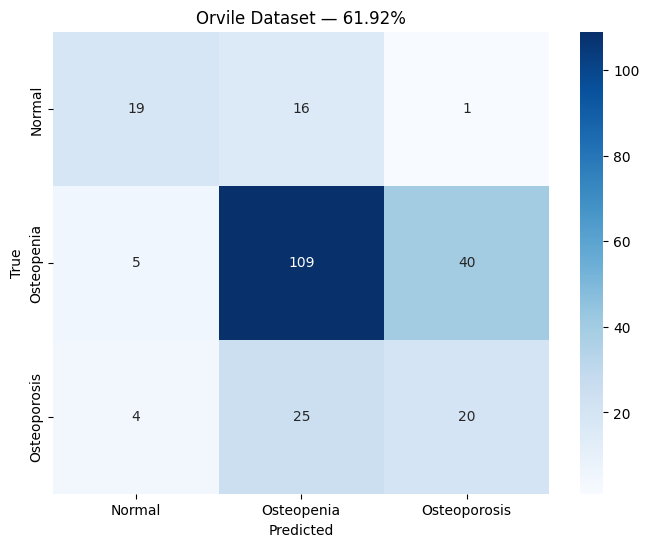


Testing on Sachinkumar dataset (Normal vs Osteoporosis only)...
Found 372 images belonging to 2 classes.
Found 372 images belonging to 2 classes.
Found 372 images belonging to 2 classes.
 TTA round 1/10 done
Found 372 images belonging to 2 classes.
Found 372 images belonging to 2 classes.
Found 372 images belonging to 2 classes.
 TTA round 2/10 done
Found 372 images belonging to 2 classes.
Found 372 images belonging to 2 classes.
Found 372 images belonging to 2 classes.
 TTA round 3/10 done
Found 372 images belonging to 2 classes.
Found 372 images belonging to 2 classes.
Found 372 images belonging to 2 classes.
 TTA round 4/10 done
Found 372 images belonging to 2 classes.
Found 372 images belonging to 2 classes.
Found 372 images belonging to 2 classes.
 TTA round 5/10 done
Found 372 images belonging to 2 classes.
Found 372 images belonging to 2 classes.
Found 372 images belonging to 2 classes.
 TTA round 6/10 done
Found 372 images belonging to 2 classes.
Found 372 images belonging to 

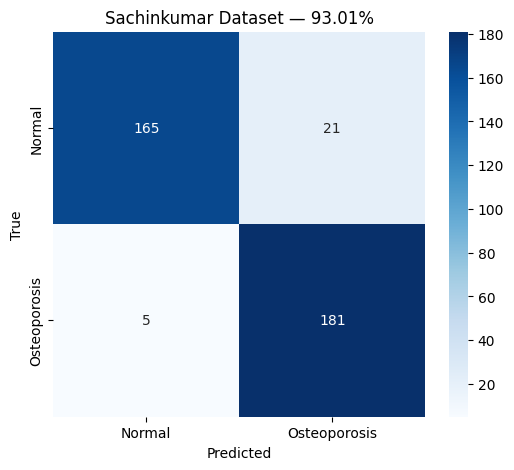

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

class_names = ['Normal', 'Osteopenia', 'Osteoporosis']

def ensemble_predict_from_folder(folder, preprocess_vgg, preprocess_res, preprocess_eff, n_tta=10):
 total = sum(
  len(os.listdir(os.path.join(folder, c)))
  for c in os.listdir(folder)
  if os.path.isdir(os.path.join(folder, c))
 )
 preds_vgg = np.zeros((total, 3))
 preds_res = np.zeros((total, 3))
 preds_eff = np.zeros((total, 3))
 tta_datagen_vgg = ImageDataGenerator(rotation_range=5, horizontal_flip=True, zoom_range=0.03, preprocessing_function=preprocess_vgg)
 tta_datagen_res = ImageDataGenerator(rotation_range=5, horizontal_flip=True, zoom_range=0.03, preprocessing_function=preprocess_res)
 tta_datagen_eff = ImageDataGenerator(rotation_range=5, horizontal_flip=True, zoom_range=0.03, preprocessing_function=preprocess_eff)
 classes = sorted(os.listdir(folder))
 classes = [c for c in classes if os.path.isdir(os.path.join(folder, c))]
 for i in range(n_tta):
  for datagen, preds, model in [
   (tta_datagen_vgg, preds_vgg, m_vgg),
   (tta_datagen_res, preds_res, m_res),
   (tta_datagen_eff, preds_eff, m_eff)
  ]:
   gen = datagen.flow_from_directory(
    folder, target_size=(224, 224), batch_size=1,
    classes=classes, class_mode='categorical', shuffle=False)
   gen.reset()
   preds += model.predict(gen, steps=len(gen), verbose=0)
  print(f" TTA round {i+1}/{n_tta} done")
 preds_vgg /= n_tta
 preds_res /= n_tta
 preds_eff /= n_tta
 ensemble = (preds_vgg + preds_res + preds_eff) / 3
 label_gen = ImageDataGenerator(preprocessing_function=preprocess_vgg).flow_from_directory(
  folder, target_size=(224, 224), batch_size=1,
  classes=classes, class_mode='categorical', shuffle=False)
 y_true = label_gen.classes
 return ensemble, y_true, classes

def show_results(ensemble, y_true, dataset_name, label_names):
 y_pred = np.argmax(ensemble, axis=1)
 acc = np.sum(y_pred == y_true) / len(y_true)
 print(f"\n{'='*50}")
 print(f"Dataset: {dataset_name}")
 print(f"Total images: {len(y_true)}")
 print(f"Accuracy: {acc*100:.2f}%")
 print(f"{'='*50}")
 print(classification_report(y_true, y_pred, target_names=label_names))
 cm = confusion_matrix(y_true, y_pred)
 plt.figure(figsize=(8, 6))
 sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names, cmap='Blues')
 plt.xlabel('Predicted')
 plt.ylabel('True')
 plt.title(f'{dataset_name} — {acc*100:.2f}%')
 plt.show()

# ── Test on Orvile dataset (3 classes) ──
print("\nTesting on Orvile dataset...")
orvile_dir = os.path.join(path_orvile, "Osteoporosis Knee X-ray")

# Rename folders to match training classes
rename_map = {
 'normal': 'Normal',
 'osteopenia': 'Osteopenia',
 'osteoporosis': 'Osteoporosis'
}
for old, new in rename_map.items():
 old_path = os.path.join(orvile_dir, old)
 new_path = os.path.join(orvile_dir, new)
 if os.path.exists(old_path) and not os.path.exists(new_path):
  os.rename(old_path, new_path)
  print(f" Renamed {old} -> {new}")

ensemble_orvile, y_true_orvile, _ = ensemble_predict_from_folder(
 orvile_dir,
 tf.keras.applications.vgg19.preprocess_input,
 tf.keras.applications.resnet50.preprocess_input,
 tf.keras.applications.efficientnet.preprocess_input,
 n_tta=10
)
show_results(ensemble_orvile, y_true_orvile, "Orvile Dataset", class_names)

# ── Test on Sachinkumar dataset (2 classes only) ──
print("\nTesting on Sachinkumar dataset (Normal vs Osteoporosis only)...")
sach_dir = os.path.join(path_sach, "Osteoporosis Knee Dataset")
sach_classes = ['Normal', 'Osteoporosis']

ensemble_sach, y_true_sach, _ = ensemble_predict_from_folder(
 sach_dir,
 tf.keras.applications.vgg19.preprocess_input,
 tf.keras.applications.resnet50.preprocess_input,
 tf.keras.applications.efficientnet.preprocess_input,
 n_tta=10
)

# For Sachinkumar remap predictions to only Normal/Osteoporosis
# Class indices from flow_from_directory will be Normal=0, Osteoporosis=1
# But our model outputs 3 classes: Normal=0, Osteopenia=1, Osteoporosis=2
# So we combine Osteopenia predictions into Osteoporosis
sach_ensemble_2class = np.zeros((len(y_true_sach), 2))
sach_ensemble_2class[:, 0] = ensemble_sach[:, 0]  # Normal
sach_ensemble_2class[:, 1] = ensemble_sach[:, 1] + ensemble_sach[:, 2]  # Osteopenia+Osteoporosis -> Osteoporosis

y_pred_sach = np.argmax(sach_ensemble_2class, axis=1)
acc_sach = np.sum(y_pred_sach == y_true_sach) / len(y_true_sach)

print(f"\n{'='*50}")
print(f"Dataset: Sachinkumar (2-class)")
print(f"Total images: {len(y_true_sach)}")
print(f"Accuracy: {acc_sach*100:.2f}%")
print(f"{'='*50}")
print(classification_report(y_true_sach, y_pred_sach, target_names=sach_classes))

cm_sach = confusion_matrix(y_true_sach, y_pred_sach)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_sach, annot=True, fmt='d', xticklabels=sach_classes, yticklabels=sach_classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Sachinkumar Dataset — {acc_sach*100:.2f}%')
plt.show()

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("="*55)
print("BINARY EVALUATION: Normal vs Osteoporosis")
print("(Osteopenia merged into Osteoporosis)")
print("="*55)

def binary_ensemble_predict(folder, n_tta=10):
 # Count total images
 total = sum(
  len(os.listdir(os.path.join(folder, c)))
  for c in os.listdir(folder)
  if os.path.isdir(os.path.join(folder, c))
 )

 classes = sorted([
  c for c in os.listdir(folder)
  if os.path.isdir(os.path.join(folder, c))
 ])

 preds_vgg = np.zeros((total, 3))
 preds_res = np.zeros((total, 3))
 preds_eff = np.zeros((total, 3))

 for i in range(n_tta):
  for model, preprocess_fn, preds in [
   (m_vgg, tf.keras.applications.vgg19.preprocess_input, preds_vgg),
   (m_res, tf.keras.applications.resnet50.preprocess_input, preds_res),
   (m_eff, tf.keras.applications.efficientnet.preprocess_input, preds_eff),
  ]:
   datagen = ImageDataGenerator(
    rotation_range=5,
    horizontal_flip=True,
    zoom_range=0.03,
    preprocessing_function=preprocess_fn
   )
   gen = datagen.flow_from_directory(
    folder, target_size=(224, 224), batch_size=1,
    classes=classes, class_mode='categorical', shuffle=False)
   gen.reset()
   preds += model.predict(gen, steps=len(gen), verbose=0)
  print(f" TTA round {i+1}/{n_tta} done")

 preds_vgg /= n_tta
 preds_res /= n_tta
 preds_eff /= n_tta
 ensemble = (preds_vgg + preds_res + preds_eff) / 3

 # Get true labels
 label_gen = ImageDataGenerator(
  preprocessing_function=tf.keras.applications.vgg19.preprocess_input
 ).flow_from_directory(
  folder, target_size=(224, 224), batch_size=1,
  classes=classes, class_mode='categorical', shuffle=False)
 y_true_3class = label_gen.classes

 return ensemble, y_true_3class, classes

def convert_to_binary(ensemble, y_true_3class, classes):
 """
 Convert 3-class predictions to binary.
 Normal stays Normal.
 Osteopenia + Osteoporosis -> Osteoporosis (non-normal).
 Model output: Normal=0, Osteopenia=1, Osteoporosis=2
 """
 # Binary predictions: Normal=0, Osteoporosis=1
 binary_preds = np.zeros((len(ensemble), 2))
 binary_preds[:, 0] = ensemble[:, 0]             # Normal probability
 binary_preds[:, 1] = ensemble[:, 1] + ensemble[:, 2]  # Osteopenia+Osteoporosis

 y_pred_binary = np.argmax(binary_preds, axis=1)

 # Convert true labels to binary
 # Find which index is Normal in the sorted classes list
 normal_idx = classes.index('Normal') if 'Normal' in classes else -1

 # Everything that is not Normal becomes Osteoporosis (1)
 y_true_binary = np.where(y_true_3class == normal_idx, 0, 1)

 return y_pred_binary, y_true_binary

def show_binary_results(y_pred, y_true, dataset_name, total_images):
 binary_names = ['Normal', 'Osteoporosis']
 acc = np.sum(y_pred == y_true) / len(y_true)

 print(f"\n{'='*55}")
 print(f"Dataset: {dataset_name}")
 print(f"Total images: {total_images}")
 print(f"Binary Accuracy: {acc*100:.2f}%")
 print(f"{'='*55}")
 print(classification_report(y_true, y_pred, target_names=binary_names))

 cm = confusion_matrix(y_true, y_pred)
 plt.figure(figsize=(6, 5))
 sns.heatmap(cm, annot=True, fmt='d',
  xticklabels=binary_names,
  yticklabels=binary_names,
  cmap='Blues')
 plt.xlabel('Predicted')
 plt.ylabel('True')
 plt.title(f'{dataset_name} Binary — {acc*100:.2f}%')
 plt.show()
 return acc

results_summary = {}

# ── Dataset 1: Our own test set ──
print("\n[1/4] Testing on OUR TEST SET...")
test_dir = "/tmp/osteoporosis_merged/test"
ensemble1, y_true1, classes1 = binary_ensemble_predict(test_dir, n_tta=10)
y_pred1, y_true_b1 = convert_to_binary(ensemble1, y_true1, classes1)
acc1 = show_binary_results(y_pred1, y_true_b1, "Our Test Set", len(y_true1))
results_summary["Our Test Set"] = acc1

# ── Dataset 2: Orvile (3-class external) ──
print("\n[2/4] Testing on ORVILE DATASET...")
orvile_dir = os.path.join(path_orvile, "Osteoporosis Knee X-ray")

# Make sure folders are renamed to match
rename_map = {'normal': 'Normal', 'osteopenia': 'Osteopenia', 'osteoporosis': 'Osteoporosis'}
for old, new in rename_map.items():
 old_path = os.path.join(orvile_dir, old)
 new_path = os.path.join(orvile_dir, new)
 if os.path.exists(old_path) and not os.path.exists(new_path):
  os.rename(old_path, new_path)

ensemble2, y_true2, classes2 = binary_ensemble_predict(orvile_dir, n_tta=10)
y_pred2, y_true_b2 = convert_to_binary(ensemble2, y_true2, classes2)
acc2 = show_binary_results(y_pred2, y_true_b2, "Orvile Dataset", len(y_true2))
results_summary["Orvile Dataset"] = acc2

# ── Dataset 3: Sachinkumar (already binary) ──
print("\n[3/4] Testing on SACHINKUMAR DATASET...")
sach_dir = os.path.join(path_sach, "Osteoporosis Knee Dataset")

# Sachinkumar only has Normal and Osteoporosis folders
# flow_from_directory will assign Normal=0, Osteoporosis=1
sach_preds_vgg = np.zeros((372, 3))
sach_preds_res = np.zeros((372, 3))
sach_preds_eff = np.zeros((372, 3))

sach_classes = ['Normal', 'Osteoporosis']

for i in range(10):
 for model, preprocess_fn, preds in [
  (m_vgg, tf.keras.applications.vgg19.preprocess_input, sach_preds_vgg),
  (m_res, tf.keras.applications.resnet50.preprocess_input, sach_preds_res),
  (m_eff, tf.keras.applications.efficientnet.preprocess_input, sach_preds_eff),
 ]:
  datagen = ImageDataGenerator(
   rotation_range=5, horizontal_flip=True,
   zoom_range=0.03, preprocessing_function=preprocess_fn)
  gen = datagen.flow_from_directory(
   sach_dir, target_size=(224, 224), batch_size=1,
   classes=sach_classes, class_mode='categorical', shuffle=False)
  gen.reset()
  preds += model.predict(gen, steps=len(gen), verbose=0)
 print(f" TTA round {i+1}/10 done")

sach_preds_vgg /= 10
sach_preds_res /= 10
sach_preds_eff /= 10
sach_ensemble = (sach_preds_vgg + sach_preds_res + sach_preds_eff) / 3

# Remap to binary: Normal=0, Osteoporosis=1
sach_binary = np.zeros((372, 2))
sach_binary[:, 0] = sach_ensemble[:, 0]             # Normal
sach_binary[:, 1] = sach_ensemble[:, 1] + sach_ensemble[:, 2]  # merge

label_gen_sach = ImageDataGenerator(
 preprocessing_function=tf.keras.applications.vgg19.preprocess_input
).flow_from_directory(
 sach_dir, target_size=(224, 224), batch_size=1,
 classes=sach_classes, class_mode='categorical', shuffle=False)
y_true_sach = label_gen_sach.classes

y_pred_sach = np.argmax(sach_binary, axis=1)
acc3 = show_binary_results(y_pred_sach, y_true_sach, "Sachinkumar Dataset", 372)
results_summary["Sachinkumar Dataset"] = acc3

# ── Dataset 4: Full merged training dataset (D1+D2 combined) ──
print("\n[4/4] Testing on FULL D1+D2 MERGED DATASET...")

# Create a temp folder with all images from D1 and D2 combined
full_dir = "/tmp/full_combined"
for cls in ['Normal', 'Osteopenia', 'Osteoporosis']:
 os.makedirs(os.path.join(full_dir, cls), exist_ok=True)

import shutil

# Copy from D1
d1_base = os.path.join(path1, "OS Collected Data")
for cls in ['Normal', 'Osteopenia', 'Osteoporosis']:
 src = os.path.join(d1_base, cls)
 dst = os.path.join(full_dir, cls)
 if os.path.exists(src):
  for i, f in enumerate(os.listdir(src)):
   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
    shutil.copy2(os.path.join(src, f), os.path.join(dst, f"d1_{i}_{f}"))

# Copy Normal and Osteoporosis from D2
d2_map = {
 'Normal': os.path.join(path2, "normal", "normal"),
 'Osteoporosis': os.path.join(path2, "osteoporosis", "osteoporosis")
}
for cls, src in d2_map.items():
 dst = os.path.join(full_dir, cls)
 if os.path.exists(src):
  for i, f in enumerate(os.listdir(src)):
   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
    shutil.copy2(os.path.join(src, f), os.path.join(dst, f"d2_{i}_{f}"))

# Count
for cls in ['Normal', 'Osteopenia', 'Osteoporosis']:
 n = len(os.listdir(os.path.join(full_dir, cls)))
 print(f" {cls}: {n} images")

ensemble4, y_true4, classes4 = binary_ensemble_predict(full_dir, n_tta=10)
y_pred4, y_true_b4 = convert_to_binary(ensemble4, y_true4, classes4)
acc4 = show_binary_results(y_pred4, y_true_b4, "Full D1+D2 Dataset", len(y_true4))
results_summary["Full D1+D2 Dataset"] = acc4

# ── Final Summary ──
print("\n" + "="*55)
print("BINARY CLASSIFICATION SUMMARY")
print("Normal vs Osteoporosis (Osteopenia merged)")
print("="*55)
for dataset, acc in results_summary.items():
 print(f"{dataset:30s}: {acc*100:.2f}%")

# Bar chart summary
plt.figure(figsize=(10, 5))
plt.bar(results_summary.keys(), [v*100 for v in results_summary.values()],
 color=['royalblue', 'orange', 'green', 'red'])
plt.ylabel('Accuracy (%)')
plt.title('Binary Classification Accuracy Across All Datasets')
plt.ylim(50, 100)
for i, (k, v) in enumerate(results_summary.items()):
 plt.text(i, v*100 + 0.5, f'{v*100:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()